In [1]:
import pandas as pd

# 訓練（train）データとテスト（test）データを読み込む
train_df = pd.read_csv("data/train.csv")
test_df = pd.read_csv("data/test.csv")

# データの行数（データ数）と列数（特徴の種類）を確認
print(f"訓練データのサイズ: {train_df.shape}")
print(f"テストデータのサイズ: {test_df.shape}")

# 訓練データの最初の5行を表示
train_df.head()

訓練データのサイズ: (594194, 21)
テストデータのサイズ: (254655, 20)


,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


Train Shape: (594194, 21)
Test Shape: (254655, 20)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract         

None


Target Distribution:
Churn
No     0.774792
Yes    0.225208
Name: proportion, dtype: float64


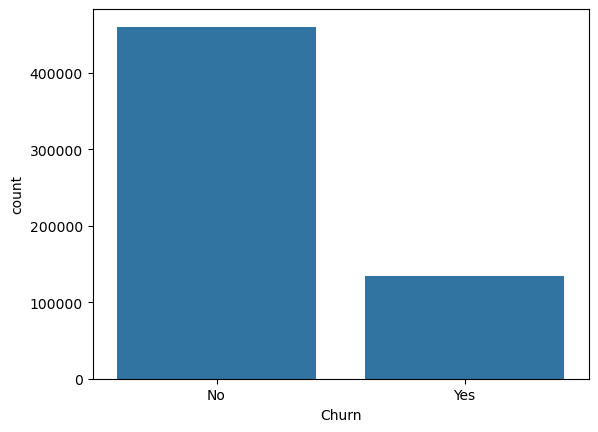

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# データの読み込み
train = pd.read_csv("data/train.csv")
test = pd.read_csv("data/test.csv")

# 1. 基本情報の確認
print(f"Train Shape: {train.shape}")
print(f"Test Shape: {test.shape}")

# 2. 欠損値とデータ型の確認
display(train.info())

# 3. 目的変数（Churn）のバランス確認（クラス不均衡のチェック）
print("\nTarget Distribution:")
print(train['Churn'].value_counts(normalize=True))
sns.countplot(x='Churn', data=train)
plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/Caskroom/miniconda/base/

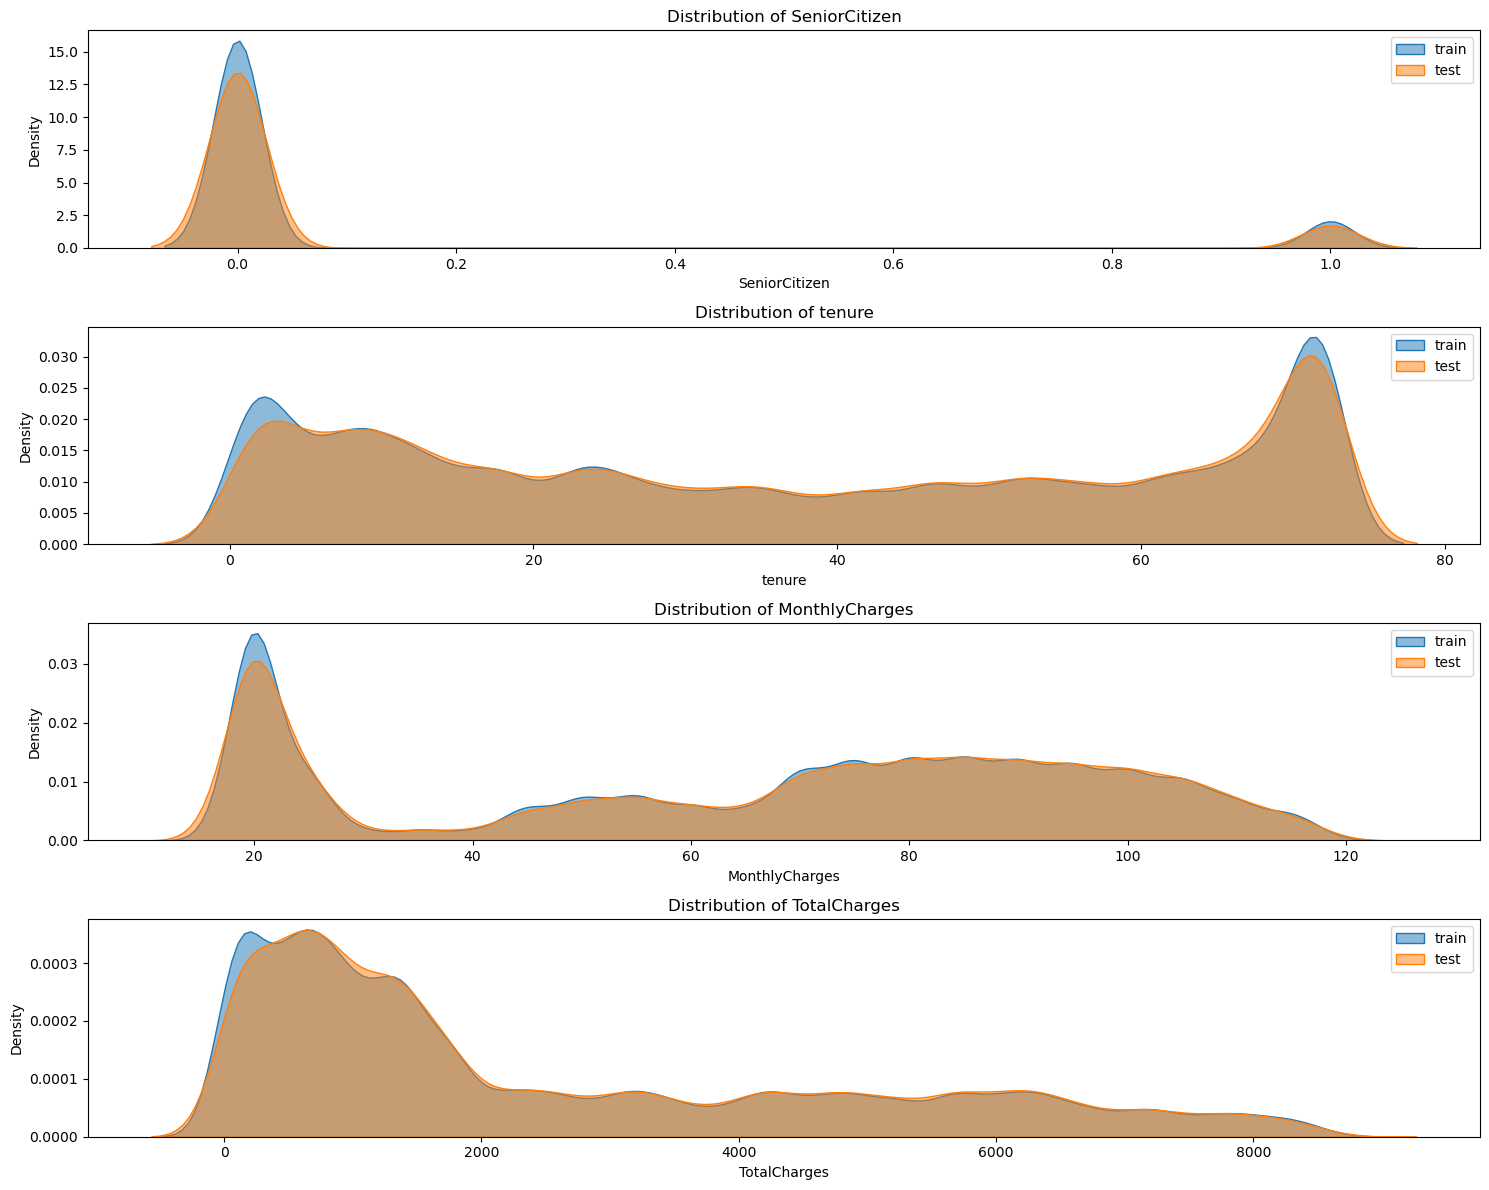

In [3]:
# 数値カラムの抽出（ID系を除く）
num_features = train.select_dtypes(include=['int64', 'float64']).columns.drop(['id', 'Churn'], errors='ignore')

# 分布の比較可視化
plt.figure(figsize=(15, len(num_features) * 3))
for i, col in enumerate(num_features):
    plt.subplot(len(num_features), 1, i + 1)
    sns.kdeplot(train[col], label='train', fill=True, alpha=0.5)
    sns.kdeplot(test[col], label='test', fill=True, alpha=0.5)
    plt.title(f'Distribution of {col}')
    plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# Churn列のユニークな値を確認
print("Current Churn values:", train['Churn'].unique())

# 文字列（例: 'Yes'/'No'）だった場合、0と1に変換
# もし既に数値(0,1)ならこの処理は何もしません
if train['Churn'].dtype == 'object':
    # 例: 'Yes'を1、'No'を0に変換（実際のラベル名に合わせて調整してください）
    # もしラベルが 'Exited' なら {'Exited': 1, 'Stayed': 0} など
    target_mapping = {'Yes': 1, 'No': 0} 
    # もし上の値と違う場合は、uniqueの結果を見て書き換えてください
    train['Churn'] = train['Churn'].map(target_mapping)

# その後で、改めて相関を計算
corr_matrix = train.corr(numeric_only=True)
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)
print(churn_corr)

Current Churn values: ['No' 'Yes']
Churn             1.000000
MonthlyCharges    0.272997
SeniorCitizen     0.236362
id               -0.012971
TotalCharges     -0.218365
tenure           -0.418453
Name: Churn, dtype: float64


Correlation with Churn:
 Churn             1.000000
MonthlyCharges    0.272997
SeniorCitizen     0.236362
id               -0.012971
TotalCharges     -0.218365
tenure           -0.418453
Name: Churn, dtype: float64


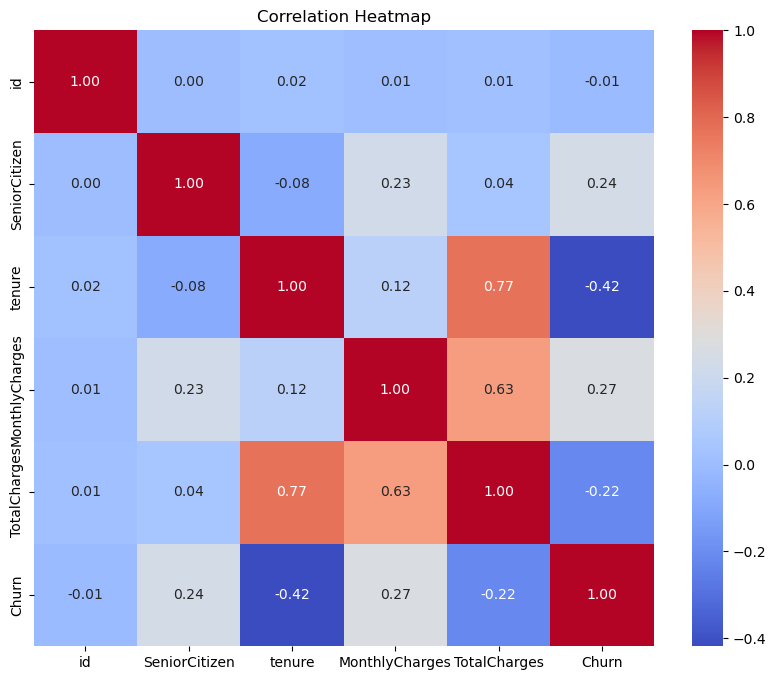

In [5]:
# 相関行列の計算
corr_matrix = train.corr(numeric_only=True)

# Churnとの相関が高い順に並び替え
churn_corr = corr_matrix['Churn'].sort_values(ascending=False)
print("Correlation with Churn:\n", churn_corr)

# ヒートマップで可視化
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/Caskroom/miniconda/base/

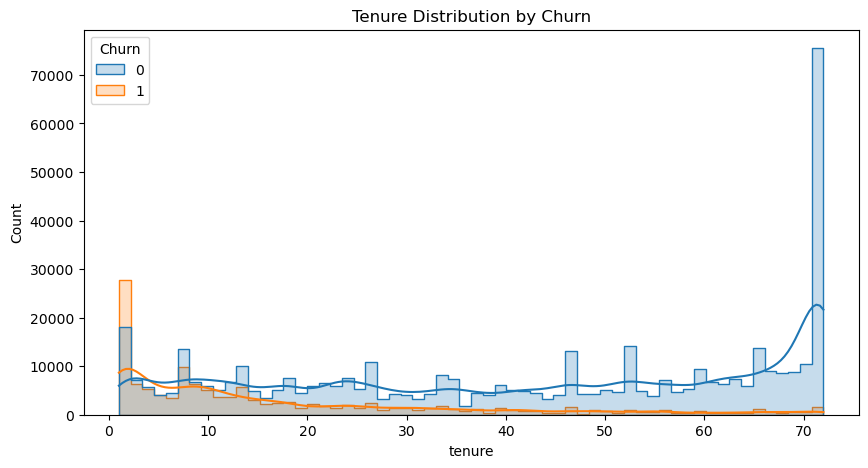

In [6]:
plt.figure(figsize=(10, 5))
# 契約期間ごとの退会・継続の分布
sns.histplot(data=train, x='tenure', hue='Churn', kde=True, element="step")
plt.title('Tenure Distribution by Churn')
plt.show()

/opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: invalid value encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: divide by zero encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/Caskroom/miniconda/base/envs/myenv/lib/python3.13/site-packages/scipy/_lib/_util.py:1279: RuntimeWarning: overflow encountered in vecdot
  return np.vecdot(x1, x2, axis=axis)
/opt/homebrew/Caskroom/miniconda/base/

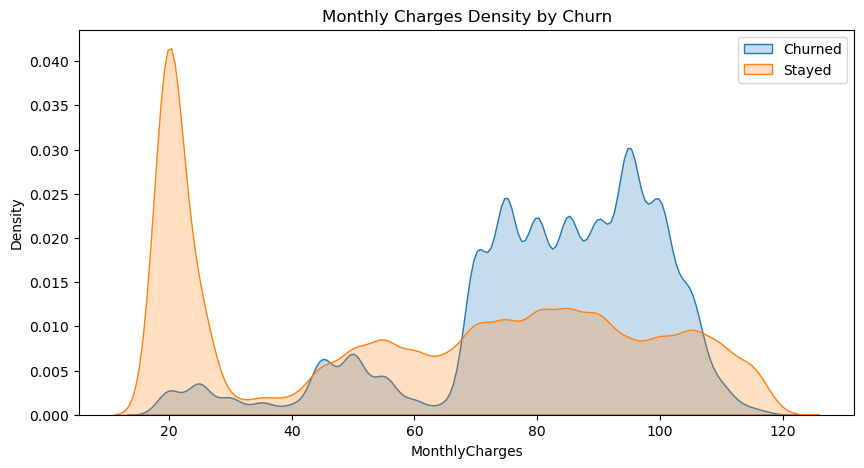

In [7]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=train[train['Churn']==1]['MonthlyCharges'], label='Churned', fill=True)
sns.kdeplot(data=train[train['Churn']==0]['MonthlyCharges'], label='Stayed', fill=True)
plt.title('Monthly Charges Density by Churn')
plt.legend()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import lightgbm as lgb
import numpy as np

# 1. データのコピーと不要な列の削除
X = train.drop(['id', 'Churn'], axis=1)
y = train['Churn']
X_test = test.drop(['id'], axis=1)

# 2. カテゴリ変数の処理（Label Encoding）
# LightGBMは文字列のままでも扱えますが、まずは基本のLabelEncoderで数値化します
cat_features = X.select_dtypes(include=['object']).columns

for col in cat_features:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col].astype(str))
    X_test[col] = le.transform(X_test[col].astype(str))

In [9]:
# データを学習用と検証用に分割（8:2）
# stratify=y を入れることで、退会した人の割合が偏らないようにします
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# LightGBM専用のデータ形式に変換
train_set = lgb.Dataset(X_train, label=y_train)
valid_set = lgb.Dataset(X_valid, label=y_valid, reference=train_set)

# 基本的なパラメータ設定
params = {
    'objective': 'binary',    # 二値分類
    'metric': 'auc',         # 評価指標はAUC（Kaggleの churn コンペで一般的）
    'verbosity': -1,         # ログをスッキリさせる
    'boosting_type': 'gbdt', # 勾配ブースティング決定木
    'random_state': 42
}

# 学習開始
print("Starting training...")
model = lgb.train(
    params,
    train_set,
    valid_sets=[train_set, valid_set],
    valid_names=['train', 'valid'],
    num_boost_round=1000,           # 最大1000回学習
    callbacks=[
        lgb.early_stopping(stopping_rounds=50), # 50回スコアが上がらなければ中止
        lgb.log_evaluation(50)                  # 50回ごとにログを表示
    ]
)

print("\nBest AUC Score:", model.best_score['valid']['auc'])

Starting training...
Training until validation scores don't improve for 50 rounds
[50]	train's auc: 0.914305	valid's auc: 0.913847
[100]	train's auc: 0.916766	valid's auc: 0.915294
[150]	train's auc: 0.918293	valid's auc: 0.915747
[200]	train's auc: 0.919461	valid's auc: 0.915912
[250]	train's auc: 0.920435	valid's auc: 0.915982
[300]	train's auc: 0.921339	valid's auc: 0.916057
[350]	train's auc: 0.922181	valid's auc: 0.916061
[400]	train's auc: 0.923001	valid's auc: 0.916077
[450]	train's auc: 0.923786	valid's auc: 0.916085
Early stopping, best iteration is:
[429]	train's auc: 0.92346	valid's auc: 0.916096

Best AUC Score: 0.9160961186630929


In [10]:
# 1. 学習に使った特徴量の名前リストを取得
feature_names = model.feature_name()

# 2. X_test を、学習時と同じ列・同じ順番だけに絞り込む
X_test_filtered = X_test[feature_names]

# 3. 再度予測を実行
test_preds = model.predict(X_test_filtered, num_iteration=model.best_iteration)

print("Prediction successful!")

Prediction successful!


In [11]:
# 提出用テンプレートの読み込み
submission = pd.read_csv("data/sample_submission.csv")

# 予測値を代入
submission['Churn'] = test_preds

# 保存
submission.to_csv("submission_baseline.csv", index=False)
print("submission_baseline.csv has been created!")

submission_baseline.csv has been created!


In [12]:
submission.head()

,id,Churn
0,594194,0.061132
1,594195,0.000336
2,594196,0.134050
3,594197,0.004369
4,594198,0.518093
